# Softmax Multiclass Classifier on MNIST

Single-layer Softmax classifier applied to MNIST digit recognition. Demonstrates cross-entropy loss, class probability calibration, and per-class accuracy analysis.

In [ ]:
# !conda install -y torchvision

import torch
import torch.nn as nn
import torchvision.transforms as transforms
import torchvision.datasets as dsets
import matplotlib.pylab as plt
import numpy as np

In [ ]:
# The function to plot parameters

def PlotParameters(model):
    W = model.state_dict()['linear.weight'].data
    w_min = W.min().item()
    w_max = W.max().item()
    fig, axes = plt.subplots(2, 5)
    fig.subplots_adjust(hspace=0.01, wspace=0.1)
    for i, ax in enumerate(axes.flat):
        if i < 10:

            # Set the label for the sub-plot.
            ax.set_xlabel("class: {0}".format(i))

            # Plot the image.
            ax.imshow(W[i, :].view(28, 28), vmin=w_min, vmax=w_max, cmap='seismic')

            ax.set_xticks([])
            ax.set_yticks([])

        # Ensure the plot is shown correctly with multiple plots
        # in a single Notebook cell.
    plt.show()

In [ ]:
# Plot the data

def show_data(data_sample):
    plt.imshow(data_sample[0].numpy().reshape(28, 28), cmap='gray')
    #plt.title('y = ' + str(data_sample[1].item()))

# Make Some Data
Load the training dataset by setting the parameters `train` to `True` and convert it to a tensor by placing a transform object in the argument `transform`.

In [ ]:
# Create and print the training dataset

train_dataset = dsets.MNIST(root='./data', train=True, download=True, transform=transforms.ToTensor())
print("Print the training dataset:\n ", train_dataset)

Print the training dataset:
  Dataset MNIST
    Number of datapoints: 60000
    Root location: ./data
    Split: Train
    StandardTransform
Transform: ToTensor()


Load the training dataset by setting the parameters `train` to `False` and convert it to a tensor by placing a transform object in the argument `transform`.

In [ ]:
# Create and print the validating dataset

validation_dataset = dsets.MNIST(root='./data', train=False, download=True, transform=transforms.ToTensor())
print("Print the validating dataset:\n ", validation_dataset)

Print the validating dataset:
  Dataset MNIST
    Number of datapoints: 10000
    Root location: ./data
    Split: Test
    StandardTransform
Transform: ToTensor()


In [ ]:
# Print the type of the element

print("Type of data element: ", train_dataset[0][1].type())

AttributeError: 'int' object has no attribute 'type'

![image.png](attachment:image.png)
Print out the label of the fourth element:

In [ ]:
# Print the label

print("The label: ", train_dataset[3][1])

The label:  1


Plot the fourth sample:

The image:  None


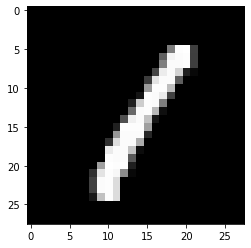

In [ ]:
# Plot the image

print("The image: ", show_data(train_dataset[3]))

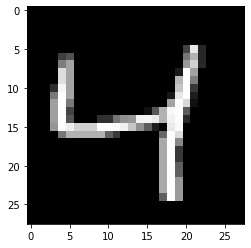

In [ ]:
# Plot the image

show_data(train_dataset[2])

## Build a Softmax Classifer
Build a Softmax classifier class:

In [ ]:
# Define softmax classifier class

class SoftMax(nn.Module):

    # Constructor
    def __init__(self, input_size, output_size):
        super(SoftMax, self).__init__()
        self.linear = nn.Linear(input_size, output_size)

    # Prediction
    def forward(self, x):
        z = self.linear(x)
        return z

The Softmax function requires vector inputs. Note that the vector shape is 28x28

In [ ]:
# Print the shape of train dataset

train_dataset[0][0].shape

torch.Size([1, 28, 28])

![image.png](attachment:image.png)

In [ ]:
# Set input size and output size

input_dim = 28 * 28
output_dim = 10

## Define the Softmax Classifier, Criterion Function, Optimizer, and Train the Model

In [ ]:
# Create the model

model = SoftMax(input_dim, output_dim)
print("Print the model:\n ", model)

Print the model:
  SoftMax(
  (linear): Linear(in_features=784, out_features=10, bias=True)
)


View the size of the model parameters:

In [ ]:
# Print the parameters

print('W: ',list(model.parameters())[0].size())
print('b: ',list(model.parameters())[1].size())

W:  torch.Size([10, 784])
b:  torch.Size([10])


![image.png](attachment:image.png)

Plot the model parameters for each class as a square image:

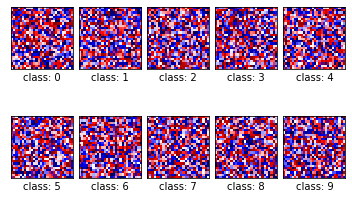

In [ ]:
# Plot the model parameters for each class

PlotParameters(model)

Define the learning rate, optimizer, criterion, data loader:

In [ ]:
# Define the learning rate, optimizer, criterion and data loader

learning_rate = 0.1
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)
criterion = nn.CrossEntropyLoss()
train_loader = torch.utils.data.DataLoader(dataset=train_dataset, batch_size=100)
validation_loader = torch.utils.data.DataLoader(dataset=validation_dataset, batch_size=5000)

Train the model and determine validation accuracy (should take a few minutes):

In [ ]:
# Train the model

n_epochs = 10
loss_list = []
accuracy_list = []
N_test = len(validation_dataset)

def train_model(n_epochs):
    for epoch in range(n_epochs):
        for x, y in train_loader:
            optimizer.zero_grad()
            z = model(x.view(-1, 28 * 28))
            loss = criterion(z, y)
            loss.backward()
            optimizer.step()

        correct = 0
        # perform a prediction on the validationdata
        for x_test, y_test in validation_loader:
            z = model(x_test.view(-1, 28 * 28))
            _, yhat = torch.max(z.data, 1)
            correct += (yhat == y_test).sum().item()
        accuracy = correct / N_test
        loss_list.append(loss.data)
        accuracy_list.append(accuracy)

train_model(n_epochs)

## Analyze Results
Plot the loss and accuracy on the validation data:

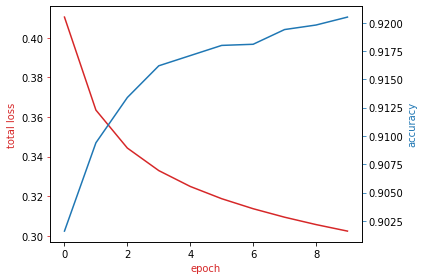

In [ ]:
# Plot the loss and accuracy

fig, ax1 = plt.subplots()
color = 'tab:red'
ax1.plot(loss_list,color=color)
ax1.set_xlabel('epoch',color=color)
ax1.set_ylabel('total loss',color=color)
ax1.tick_params(axis='y', color=color)

ax2 = ax1.twinx()
color = 'tab:blue'
ax2.set_ylabel('accuracy', color=color)
ax2.plot( accuracy_list, color=color)
ax2.tick_params(axis='y', color=color)
fig.tight_layout()

View the results of the parameters for each class after the training. You can see that they look like the corresponding numbers.

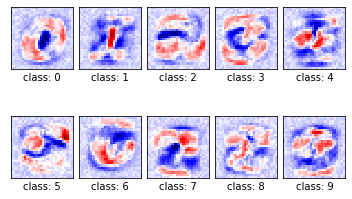

In [ ]:
# Plot the parameters

PlotParameters(model)

We Plot the first five misclassified samples and the probability of that class.

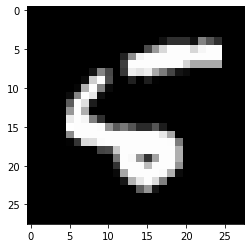

yhat: tensor([6])
probability of class  0.9903519749641418


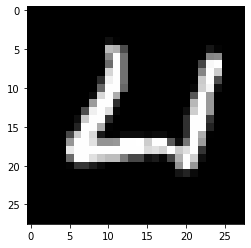

yhat: tensor([6])
probability of class  0.4659002721309662


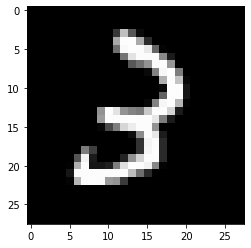

yhat: tensor([2])
probability of class  0.6930132508277893


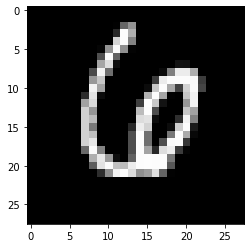

yhat: tensor([7])
probability of class  0.3470950126647949


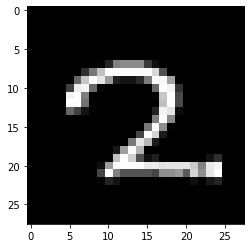

yhat: tensor([7])
probability of class  0.5180326104164124


In [ ]:
# Plot the misclassified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat != y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break

We Plot the first five correctly classified samples and the probability of that class, we see the probability is much larger.

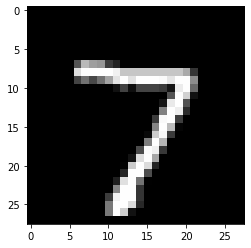

yhat: tensor([7])
probability of class  0.996681272983551


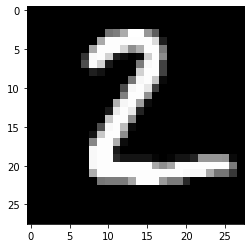

yhat: tensor([2])
probability of class  0.9478958249092102


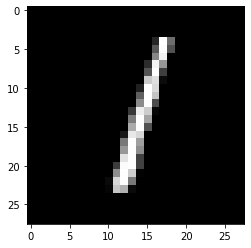

yhat: tensor([1])
probability of class  0.9764201641082764


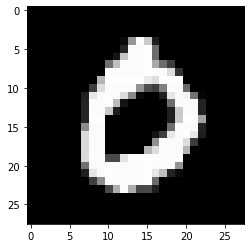

yhat: tensor([0])
probability of class  0.9995324611663818


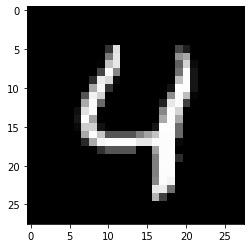

yhat: tensor([4])
probability of class  0.9447091221809387


In [ ]:
# Plot the classified samples
Softmax_fn=nn.Softmax(dim=-1)
count = 0
for x, y in validation_dataset:
    z = model(x.reshape(-1, 28 * 28))
    _, yhat = torch.max(z, 1)
    if yhat == y:
        show_data((x, y))
        plt.show()
        print("yhat:", yhat)
        print("probability of class ", torch.max(Softmax_fn(z)).item())
        count += 1
    if count >= 5:
        break